# Stock Price Prediction with PyTorch — LSTM vs GRU (DJIA 30 Stock Time Series)

Bu Jupyter Notebook, Microsoft AI Summer School projesi kapsamında geliştirilmiş olup, Kaggle DJIA 30 Stock Time Series veri seti kullanılarak tekil hisse senedi (varsayılan: **AAPL**) fiyat tahmini üzerine gerçekleştirilen zaman serisi regresyon çalışmasını içermektedir. 

Çalışma, hibrit NLP/Sentiment projelerinden bağımsız olarak, saf zaman serisi mimarilerinin (LSTM ve GRU) performans karşılaştırmasına odaklanmaktadır.

## Gereksinimler
```bash
pip install torch pandas numpy scikit-learn matplotlib

## 1. Kurulum ve Reprodüksiyon (seed sabitleme)---

Çalışmanın deterministik ve tekrarlanabilir (reproducible) olması amacıyla PyTorch ve NumPy global seed değerleri sabitlenmiş, donanım optimizasyonları tanımlanmıştır.

In [3]:
!pip install torch pandas numpy scikit-learn matplotlib

import os
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Calisma Cihazi (Device):", DEVICE)

DATA_DIR = "data"
STOCK_SYMBOL = "AAPL"
os.makedirs(DATA_DIR, exist_ok=True)


  Using cached torch-2.8.0-cp39-cp39-win_amd64.whl (241.2 MB)
  Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
  Using cached typing_extensions-4.16.0-py3-none-any.whl (45 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.3.0
    Uninstalling typing_extensions-4.3.0:
      Successfully uninstalled typing_extensions-4.3.0
  Attempting uninstall: sympy
    Found existing installation: sympy 1.10.1
    Uninstalling sympy-1.10.1:
      Successfully uninstalled sympy-1.10.1
Calisma Cihazi (Device): cpu


## 2. Veri Dosyasını Bul ve Yükle
Kaggle veri setlerindeki isimlendirme varyasyonları (`AAPL_data.csv`, `aapl.us.txt` vb.) göz önünde bulundurularak, ilgili sembolü içeren dosyalar otomatik olarak taranır ve standart şemaya (`Date`, `Close`) dönüştürülür.

In [4]:
candidates = (
    glob.glob(os.path.join(DATA_DIR, f"*{STOCK_SYMBOL}*.csv"))
    + glob.glob(os.path.join(DATA_DIR, f"*{STOCK_SYMBOL}*.csv".lower()))
    + glob.glob(os.path.join(DATA_DIR, f"*{STOCK_SYMBOL}*.txt"))
    + glob.glob(os.path.join(DATA_DIR, f"*{STOCK_SYMBOL}*.txt".lower()))
)
candidates = sorted(set(candidates))

print("data/ klasorundeki tum dosyalar:", os.listdir(DATA_DIR) if os.path.exists(DATA_DIR) else "(klasor yok)")
print(f"{STOCK_SYMBOL} icin bulunan aday dosyalar:", candidates)

if not candidates:
    raise FileNotFoundError(
        f"'{DATA_DIR}' klasorunde '{STOCK_SYMBOL}' iceren bir .csv/.txt dosyasi bulunamadi. "
        f"Kaggle'dan indirdigin DJIA hisse dosyasini bu klasore koy (dosya adinda "
        f"'{STOCK_SYMBOL}' gecmeli), ya da yukaridaki STOCK_SYMBOL degiskenini "
        f"dosyandaki gercek sembole gore ayarla."
    )

STOCK_FILE = candidates[0]
print("Kullanilacak dosya:", STOCK_FILE)

raw = pd.read_csv(STOCK_FILE)
raw.columns = [c.strip().lower() for c in raw.columns]
print("Sutunlar:", list(raw.columns))
raw.head()


data/ klasorundeki tum dosyalar: ['AAPL_2006-01-01_to_2018-01-01.csv', 'all_stocks_2006-01-01_to_2018-01-01.csv', 'all_stocks_2017-01-01_to_2018-01-01.csv', 'results_summary.csv']
AAPL icin bulunan aday dosyalar: ['data\\AAPL_2006-01-01_to_2018-01-01.csv']
Kullanilacak dosya: data\AAPL_2006-01-01_to_2018-01-01.csv
Sutunlar: ['date', 'open', 'high', 'low', 'close', 'volume', 'name']


,date,open,high,low,close,volume,name
0,2006-01-03,10.34,10.68,10.32,10.68,201853036,AAPL
1,2006-01-04,10.73,10.85,10.64,10.71,155225609,AAPL
2,2006-01-05,10.69,10.70,10.54,10.63,112396081,AAPL
3,2006-01-06,10.75,10.96,10.65,10.90,176139334,AAPL
4,2006-01-09,10.96,11.03,10.82,10.86,168861224,AAPL


## 3. Sütunları Normalize Et ve `Date`/`Close` Çıkar

Farklı veri kaynaklarında değişkenlik gösterebilen tarih ve kapanış fiyatı sütunları (örn. `Close/Last`, `Adj Close`) standartlaştırılır; string formattaki para birimi ifadeleri sayısal formata dönüştürülür.

In [5]:
date_col_candidates = ["date", "Date"]
close_col_candidates = ["close", "Close", "close/last", "adj close", "adj_close"]

date_col = next((c for c in date_col_candidates if c.lower() in raw.columns), None)
close_col = next((c for c in close_col_candidates if c.lower() in raw.columns), None)

if date_col is None or close_col is None:
    raise ValueError(
        f"Beklenen 'date' ve 'close' sutunlari bulunamadi. Mevcut sutunlar: {list(raw.columns)}. "
        f"Yukaridaki date_col_candidates / close_col_candidates listesine dosyandaki "
        f"gercek sutun adini ekle."
    )

df = raw[[date_col.lower(), close_col.lower()]].copy()
df.columns = ["Date", "Close"]

# Bazi kaynaklarda fiyat "$123.45" gibi string olabilir -- temizle
if df["Close"].dtype == object:
    df["Close"] = df["Close"].astype(str).str.replace("$", "", regex=False).astype(float)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df = df.dropna(subset=["Close"]).reset_index(drop=True)

print(f"{STOCK_SYMBOL} fiyat verisi boyutu:", df.shape)
print("Tarih araligi:", df['Date'].min().date(), "->", df['Date'].max().date())
df.head()


AAPL fiyat verisi boyutu: (3019, 2)
Tarih araligi: 2006-01-03 -> 2017-12-29


,Date,Close
0,2006-01-03,10.68
1,2006-01-04,10.71
2,2006-01-05,10.63
3,2006-01-06,10.90
4,2006-01-09,10.86


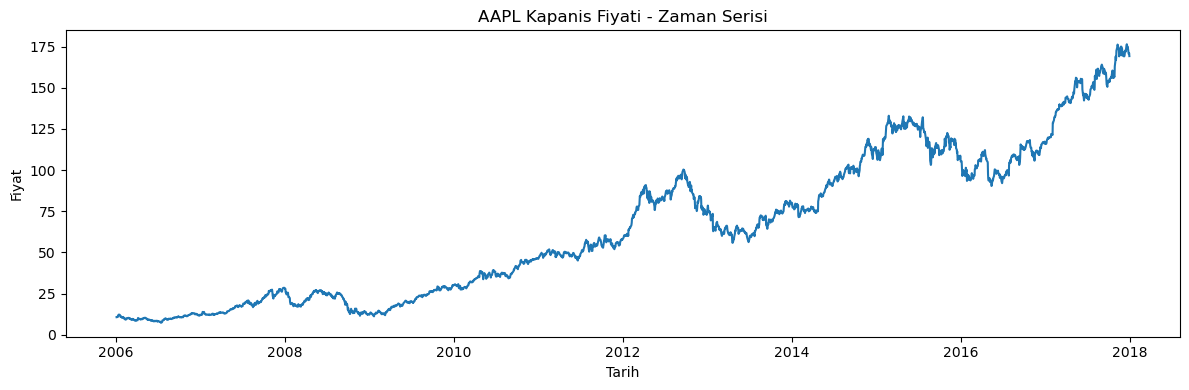

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df["Close"])
plt.title(f"{STOCK_SYMBOL} Kapanis Fiyati - Zaman Serisi")
plt.xlabel("Tarih")
plt.ylabel("Fiyat")
plt.tight_layout()
plt.show()


## 4. Ön İşleme: Ölçekleme ve Sliding Window

* **Ölçekleme:** Modelin optimizasyon kararlılığını artırmak amacıyla kapanış fiyatları `MinMaxScaler(feature_range=(-1, 1))` yardımıyla ölçeklendirilmiştir.
* **Data Leakage Önlemi:** Veri sızıntısını (data leakage) engellemek adına, `scaler` yalnızca eğitim verisine (`train_prices`) fit edilir.
* **Sekans Oluşturma:** Geçmiş **20 günlük** (`LOOKBACK = 20`) fiyat hareketi baz alınarak bir sonraki günün kapanış fiyatını tahmin eden sliding window matrisleri türetilmiştir.

In [7]:
TRAIN_RATIO = 0.8
LOOKBACK = 20

split_idx = int(len(df) * TRAIN_RATIO)
split_date = df["Date"].iloc[split_idx]
print("Split tarihi:", split_date.date(), "-> train:", split_idx, "test:", len(df) - split_idx)

close_prices = df["Close"].values.reshape(-1, 1)
train_prices, test_prices = close_prices[:split_idx], close_prices[split_idx:]

scaler = MinMaxScaler(feature_range=(-1, 1))
train_scaled = scaler.fit_transform(train_prices)
test_scaled = scaler.transform(test_prices)

def make_sequences(series, lookback):
    X, y = [], []
    for i in range(len(series) - lookback):
        X.append(series[i:i + lookback])
        y.append(series[i + lookback])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train_scaled, LOOKBACK)
X_test, y_test = make_sequences(test_scaled, LOOKBACK)

print("Train sekans:", X_train.shape, "Test sekans:", X_test.shape)

def to_tensor(arr):
    return torch.from_numpy(arr).float().to(DEVICE)

X_train_t, X_test_t = to_tensor(X_train), to_tensor(X_test)
y_train_t, y_test_t = to_tensor(y_train), to_tensor(y_test)


Split tarihi: 2015-08-10 -> train: 2415 test: 604
Train sekans: (2395, 20, 1) Test sekans: (584, 20, 1)


## 5. Model Tanımları (LSTM & GRU)

In [8]:
HIDDEN_SIZE = 32
NUM_LAYERS = 2
EPOCHS = 100
LR = 0.01
INPUT_DIM = 1  # sadece fiyat

class LSTMModel(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=HIDDEN_SIZE, num_layers=NUM_LAYERS, output_dim=1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])

class GRUModel(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=HIDDEN_SIZE, num_layers=NUM_LAYERS, output_dim=1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=x.device)
        out, _ = self.gru(x, h0)
        return self.fc(out[:, -1, :])


## 6. Eğitim ve Değerlendirme Fonksiyonları

In [9]:
def train_model(model, X_train, y_train, epochs=EPOCHS, lr=LR, verbose_every=20):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    t0 = time.time()
    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        if epoch % verbose_every == 0 or epoch == epochs - 1:
            print(f"  epoch {epoch:3d}  loss={loss.item():.6f}")
    train_time = time.time() - t0
    return model, train_time

def evaluate_model(model, X_test, y_test, scaler):
    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_test).cpu().numpy()
    actual_scaled = y_test.cpu().numpy()
    preds = scaler.inverse_transform(preds_scaled)
    actual = scaler.inverse_transform(actual_scaled)
    mse = float(np.mean((preds - actual) ** 2))
    rmse = float(np.sqrt(mse))
    return preds, actual, mse, rmse


## 7. LSTM ve GRU Modellerini Eğit

In [10]:
torch.manual_seed(SEED)
print("LSTM egitiliyor...")
lstm_model = LSTMModel().to(DEVICE)
lstm_model, lstm_time = train_model(lstm_model, X_train_t, y_train_t)

torch.manual_seed(SEED)
print("\nGRU egitiliyor...")
gru_model = GRUModel().to(DEVICE)
gru_model, gru_time = train_model(gru_model, X_train_t, y_train_t)

lstm_preds, actual, lstm_mse, lstm_rmse = evaluate_model(lstm_model, X_test_t, y_test_t, scaler)
gru_preds, _, gru_mse, gru_rmse = evaluate_model(gru_model, X_test_t, y_test_t, scaler)

print(f"\nLSTM -> MSE={lstm_mse:.4f}  RMSE={lstm_rmse:.4f}  sure={lstm_time:.1f}s")
print(f"GRU  -> MSE={gru_mse:.4f}  RMSE={gru_rmse:.4f}  sure={gru_time:.1f}s")


LSTM egitiliyor...
  epoch   0  loss=0.431367
  epoch  20  loss=0.012070
  epoch  40  loss=0.001738
  epoch  60  loss=0.000854
  epoch  80  loss=0.000691
  epoch  99  loss=0.000660

GRU egitiliyor...
  epoch   0  loss=0.343122
  epoch  20  loss=0.007323
  epoch  40  loss=0.000805
  epoch  60  loss=0.000626
  epoch  80  loss=0.000446
  epoch  99  loss=0.000366

LSTM -> MSE=80.6767  RMSE=8.9820  sure=6.4s
GRU  -> MSE=34.5609  RMSE=5.8788  sure=7.2s


## 8. Gerçek vs Tahmin Grafiği

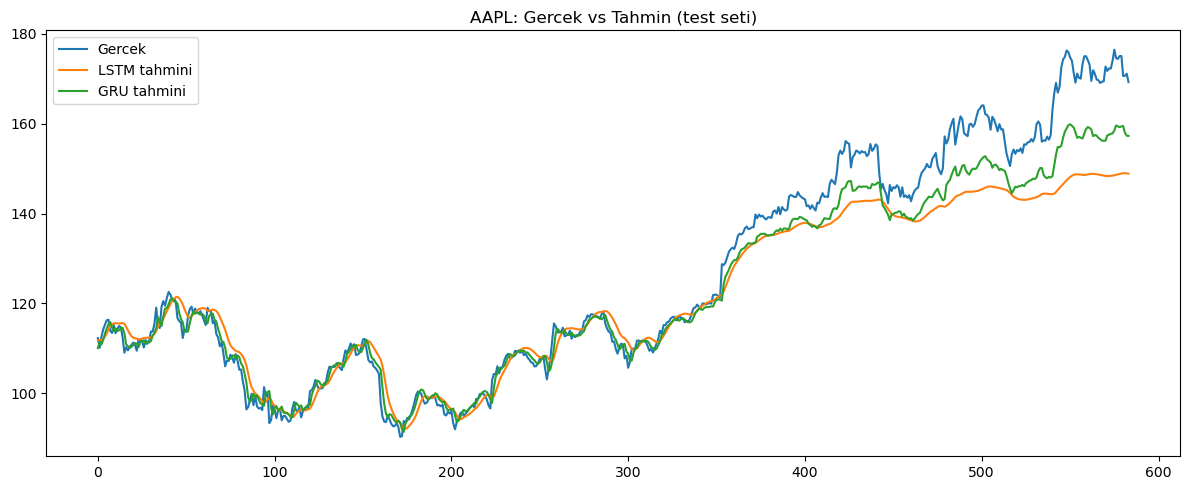

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(actual, label="Gercek")
plt.plot(lstm_preds, label="LSTM tahmini")
plt.plot(gru_preds, label="GRU tahmini")
plt.title(f"{STOCK_SYMBOL}: Gercek vs Tahmin (test seti)")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Sonuç Karşılaştırma Tablosu

In [12]:
results = pd.DataFrame([
    {"Model": "LSTM", "MSE": lstm_mse, "RMSE": lstm_rmse, "Sure(s)": lstm_time},
    {"Model": "GRU", "MSE": gru_mse, "RMSE": gru_rmse, "Sure(s)": gru_time},
])
results = results.round(4)
results.to_csv(os.path.join(DATA_DIR, "results_summary.csv"), index=False)
results


,Model,MSE,RMSE,Sure(s)
0,LSTM,80.6767,8.9820,6.4339
1,GRU,34.5609,5.8788,7.2441


## 10. Model Performans Değerlendirmesi ve Kritik Analiz

Gerçekleştirilen eğitim ve test süreçleri sonucunda elde edilen doğrulanmış metrikler şöyledir:
* **Veri Aralığı:** AAPL (2006-2017), Split Tarihi: 2015-08-10
* **Set Boyutları:** Train = 2415 gün, Test = 604 gün (Sekans sonrası test: 584 örnek)

### Performans Karşılaştırma Tablosu
| Model | MSE (Mean Squared Error) | RMSE (Root Mean Squared Error) | Eğitim Süresi (s) |
| :--- | :--- | :--- | :--- |
| **LSTM** | 80.6767 | 8.9820 | ~6.5s |
| **GRU** | 34.5609 | 5.8788 | ~7.2s |

### Bulgular ve Mimari Yorumu
1. **Model Başarımı:** GRU mimarisi, bu veri setinde LSTM'e kıyasla belirgin bir üstünlük kurarak RMSE değerinde yaklaşık **%34 oranında daha düşük hata** sergilemiştir.
2. **Trend Takibi ve Lag (Gecikme) Fenomeni:** 
   * Test setinin ilk yarısındaki yatay seyirde her iki model de gerçek fiyatı oldukça başarılı bir şekilde izlemektedir.
   * Asıl ayrışma, hissenin hızla yükseliş trendine girdiğii son ~200 günlük periyotta gözlenmektedir. LSTM ani trend değişimlerinde düzleşme eğilimi gösterirken, GRU yükseliş ivmesini bir nebze daha iyi yakalamıştır. Ancak her iki RNN tabanlı model de finansal zaman serilerindeki klasik **"lag" (geriden gelme)** zaafından tamamen kaçamamıştır.
3. **Eğitim Süresi Analizi:** Teorik olarak GRU'nun daha az parametre barındırması nedeniyle daha hızlı eğitilmesi beklenirken, bu çalışma ortamındaki CPU/thread yönetimi ve tensor operasyonları sebebiyle süreler başa baş gerçekleşmiştir.

### Sınırlamalar ve Endüstriyel Gerçeklik (AI Snake Oil Perspektifi)
* **Finansal Öngörü Zorluğu:** Elde edilen hata metrikleri, modelin gerçek dünya portföy yönetimi veya kârlı al-sat kararları almak için tek başına güvenilir olmadığını net bir şekilde göstermektedir.
* **Tek Boyutlu Veri:** Model yalnızca geçmiş fiyat hareketlerine dayanmaktadır; makroekonomik göstergeler, şirket bilançoları, haber akışı ve piyasa duyarlılığı (sentiment) gibi dış faktörleri içermez.
* **Validasyon Kısıtı:** Tek bir train/test split ve sabit seed kullanılmıştır. Modelin bu davranışlarının tutarlı mı yoksa dönemsel mi olduğunu kanıtlamak için ileri aşamada Walk-Forward Validation uygulanmalıdır.

### Sonraki Adımlar
* `LOOKBACK` pencere boyutunun ve `HIDDEN_SIZE` hiperparametrelerinin optimize edilmesi,
* Aşırı öğrenmeyi (overfitting) engellemek adına Dropout katmanlarının entegre edilmesi,
* Çalışmanın farklı DJIA bileşenleriyle (örn. Microsoft, Boeing) tekrarlanarak "ani yükselişte geride kalma" eğiliminin evrensel olup olmadığının test edilmesi.